**Задача I8.17**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

numbers = set()
numbers.add(0.0)
numbers.add(1.0)

mantissas = [
    (1, 0, 0),
    (1, 0, 1),
    (1, 1, 0),
    (1, 1, 1),
]

exponents = [2**-1, 2**0, 2**1]

for m in mantissas:
    b0, b1, b2 = m
    mantissa_value = b0 + b1*0.5 + b2*0.25

    for exp in exponents:
        value = mantissa_value * exp
        numbers.add(value)
        numbers.add(-value)

print(len(numbers), "\n", sorted(numbers))

25 
 [-3.5, -3.0, -2.5, -2.0, -1.75, -1.5, -1.25, -1.0, -0.875, -0.75, -0.625, -0.5, 0.0, 0.5, 0.625, 0.75, 0.875, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 3.5]


Машинный эпсилон - максимальный отступ от 1, который еще будет округляться в 1, в нашем случае это будет 0.125. UFL: 0.5, OFL: 3.5

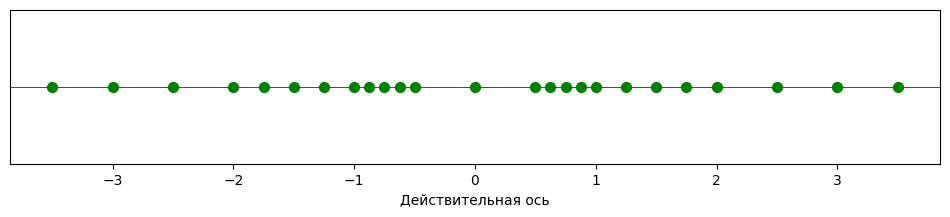

In [ ]:
numeric_numbers = [x for x in numbers if isinstance(x, (int, float))]
plt.figure(figsize=(12, 2))
plt.scatter(numeric_numbers, [0]*len(numeric_numbers), color='green', s=50, zorder=3)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.yticks([])
plt.xlabel('Действительная ось')
plt.show()

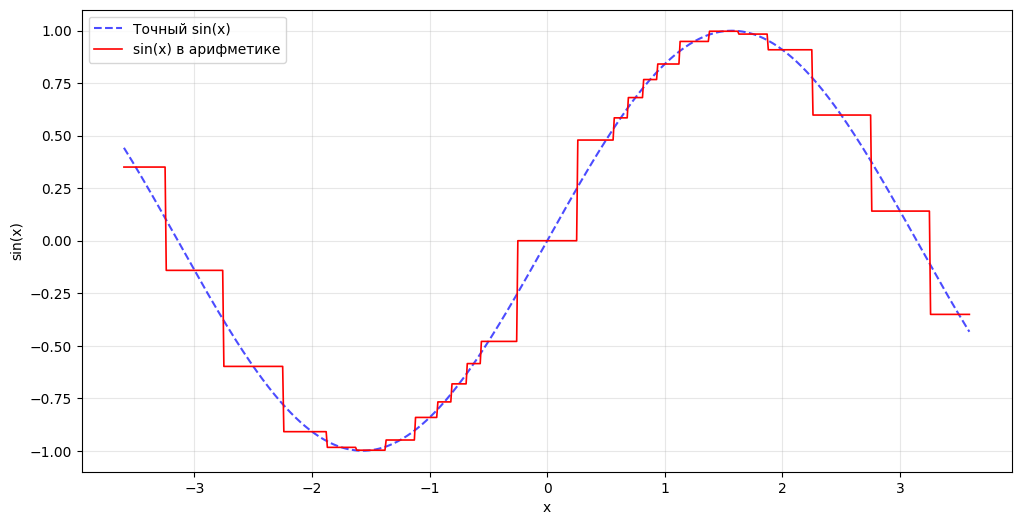

x		Точный sin(x)	Аппроксимация
---------------------------------------------
 0.000	    0.000000	    0.000000
 1.000	    0.841471	    0.841471
 0.500	    0.479426	    0.479426
-0.500	   -0.479426	   -0.479426
 2.000	    0.909297	    0.909297
 0.625	    0.585097	    0.585097
-0.625	   -0.585097	   -0.585097
 1.250	    0.948985	    0.948985
 2.500	    0.598472	    0.598472
 0.750	    0.681639	    0.681639
-0.750	   -0.681639	   -0.681639
 1.500	    0.997495	    0.997495
 3.000	    0.141120	    0.141120
 0.875	    0.767544	    0.767544
-0.875	   -0.767544	   -0.767544
 1.750	    0.983986	    0.983986
 3.500	   -0.350783	   -0.350783
-1.750	   -0.983986	   -0.983986
-3.500	    0.350783	    0.350783
-2.500	   -0.598472	   -0.598472
-1.000	   -0.841471	   -0.841471
-1.250	   -0.948985	   -0.948985
-3.000	   -0.141120	   -0.141120
-2.000	   -0.909297	   -0.909297
-1.500	   -0.997495	   -0.997495


In [ ]:
xs = [i * 0.01 for i in range(-360, 360)]
ys_model = [np.sin(min(numbers, key=lambda s: abs(s - x))) for x in xs]
ys_real = [np.sin(x) for x in xs]

plt.figure(figsize=(12, 6))
plt.plot(xs, ys_real, label="Точный sin(x)", color="blue", linestyle="--", alpha=0.7)
plt.plot(xs, ys_model, label="sin(x) в арифметике", color="red", linewidth=1.2)
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Таблица
print("x\t\tТочный sin(x)\tАппроксимация")
print("-" * 45)
for x in numbers:
    exact = np.sin(x)
    approx = np.sin(min(numbers, key=lambda s: abs(s - x)))
    print(f"{x:6.3f}\t{exact:12.6f}\t{approx:12.6f}")

ИСПРАВЛЕНИЕ

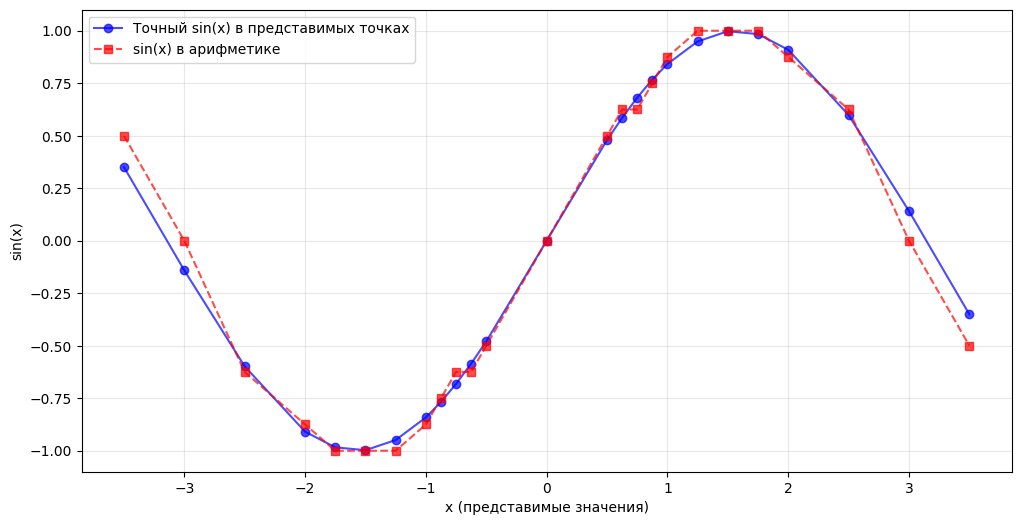

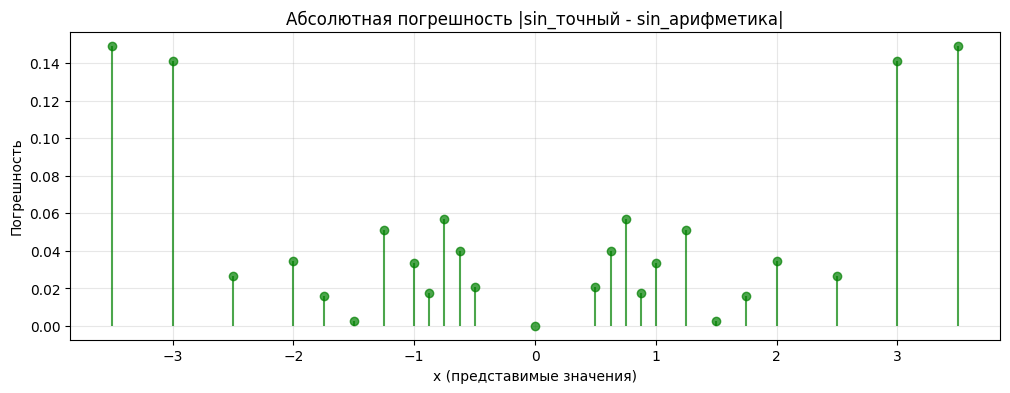

x		Точный sin(x)	Аппроксимация	Погрешность
------------------------------------------------------------
-3.500	    0.350783	    0.500000	    0.149217
-3.000	   -0.141120	    0.000000	    0.141120
-2.500	   -0.598472	   -0.625000	    0.026528
-2.000	   -0.909297	   -0.875000	    0.034297
-1.750	   -0.983986	   -1.000000	    0.016014
-1.500	   -0.997495	   -1.000000	    0.002505
-1.250	   -0.948985	   -1.000000	    0.051015
-1.000	   -0.841471	   -0.875000	    0.033529
-0.875	   -0.767544	   -0.750000	    0.017544
-0.750	   -0.681639	   -0.625000	    0.056639
-0.625	   -0.585097	   -0.625000	    0.039903
-0.500	   -0.479426	   -0.500000	    0.020574
 0.000	    0.000000	    0.000000	    0.000000
 0.500	    0.479426	    0.500000	    0.020574
 0.625	    0.585097	    0.625000	    0.039903
 0.750	    0.681639	    0.625000	    0.056639
 0.875	    0.767544	    0.750000	    0.017544
 1.000	    0.841471	    0.875000	    0.033529
 1.250	    0.948985	    1.000000	    0.051015
 1.500	    0.997495	  

In [ ]:
x_values = np.array(sorted([x for x in numbers if -2*np.pi <= x <= 2*np.pi]))

sin_exact = np.sin(x_values)

def round_to_arithmetic(x, numbers_set):
    if x == 0:
        return 0.0
    closest = min(numbers_set, key=lambda s: abs(s - x))
    return closest

sin_in_arithmetic = np.array([round_to_arithmetic(np.sin(x), numbers) for x in x_values])

plt.figure(figsize=(12, 6))
plt.plot(x_values, sin_exact, 'bo-', label="Точный sin(x) в представимых точках",
         markersize=6, linewidth=1.5, alpha=0.7)
plt.plot(x_values, sin_in_arithmetic, 'rs--', label="sin(x) в арифметике",
         markersize=6, linewidth=1.5, alpha=0.7)
plt.xlabel("x (представимые значения)")
plt.ylabel("sin(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
markerline, stemlines, baseline = plt.stem(x_values, np.abs(sin_exact - sin_in_arithmetic),
                                           linefmt='g-', markerfmt='go', basefmt=' ')
plt.setp(markerline, alpha=0.7)
plt.setp(stemlines, alpha=0.7)
plt.title("Абсолютная погрешность |sin_точный - sin_арифметика|")
plt.xlabel("x (представимые значения)")
plt.ylabel("Погрешность")
plt.grid(True, alpha=0.3)
plt.show()

print("x\t\tТочный sin(x)\tАппроксимация\tПогрешность")
print("-" * 60)
for x in sorted(numbers):
    if abs(x) <= 2*np.pi:
        exact = np.sin(x)
        approx = round_to_arithmetic(exact, numbers)
        error = abs(exact - approx)
        print(f"{x:6.3f}\t{exact:12.6f}\t{approx:12.6f}\t{error:12.6f}")

**Задача 1.2**

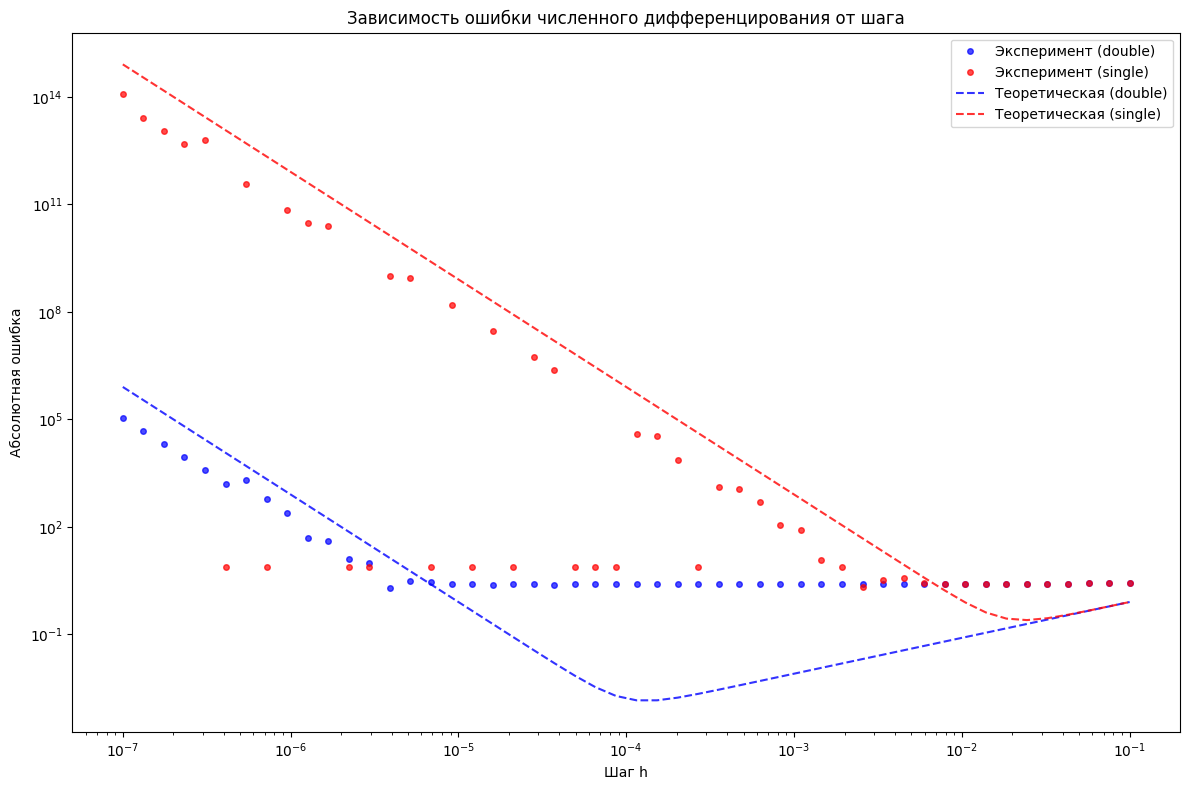

In [ ]:
def f(x):
    return np.sin(2*x)

def dif_double(x, h):
    return (4/3*f(x + h) - 4*f(x) + 4*f(x - h) - 4/3*f(x - 2*h)) / h**3

x0 = np.pi / 16
exact = -8 * np.cos(2*x0)

hs = np.logspace(-7, -1, 50)

# Double precision
errors_double = []
for h in hs:
    approx = dif_double(x0, h)
    error = abs(approx - exact)
    errors_double.append(error)

# Single precision
x0_single = np.float32(np.pi / 16)

def f_single(x):
    return np.sin(2*x, dtype=np.float32)

def dif_single(x, h):
    h = np.float32(h)
    return (4/3*f_single(x + h) - 4*f_single(x) + 4*f_single(x - h) - 4/3*f_single(x - 2*h)) / h**3

exact_single = np.float32(-8 * np.cos(2*x0_single))

errors_single = []
for h in hs:
    approx = dif_single(x0_single, np.float32(h))
    error = abs(approx - exact_single)
    errors_single.append(error)

# Теоретическая оценка ошибки
M0 = 1.0
M4 = 16.0
eps_double = 1e-16
eps_single = 1e-7

theoretical_double = (M4/2)*hs + (8*M0*eps_double)/hs**3
theoretical_single = (M4/2)*hs + (8*M0*eps_single)/hs**3

# График
plt.figure(figsize=(12, 8))
plt.loglog(hs, errors_double, 'bo', markersize=4, label='Эксперимент (double)', alpha=0.7)
plt.loglog(hs, errors_single, 'ro', markersize=4, label='Эксперимент (single)', alpha=0.7)
plt.loglog(hs, theoretical_double, 'b--', label='Теоретическая (double)', alpha=0.8)
plt.loglog(hs, theoretical_single, 'r--', label='Теоретическая (single)', alpha=0.8)

plt.xlabel('Шаг h')
plt.ylabel('Абсолютная ошибка')
plt.title('Зависимость ошибки численного дифференцирования от шага')
plt.legend()
plt.tight_layout()
plt.show()

При больших h доминирует погрешность аппроксимации.
При малых h доминирует погрешность округления.
Оптимальный h находится в точке минимума кривой.
Экспериментальные значения оптимального шага сдвинуты влево из-за недооценки погрешности округления. При больших h формула начинает давать систематическую ошибку -> параллельность оси.

ИСПРАВЛЕНИЕ

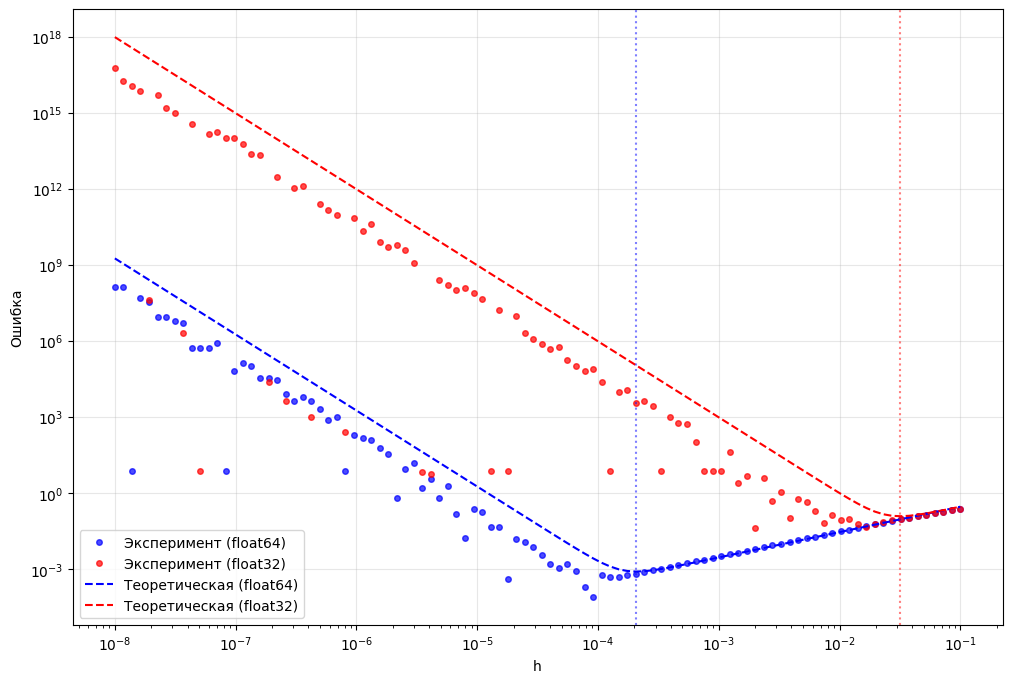

Коэффициенты: a=1.0000, b=-3.0000, c=3.0000, d=-1.0000
Порядок аппроксимации: p=1.0
C_m=2.833, C_r=8.000
ε_64=2.22e-16, ε_32=1.19e-07
h_opt_64=2.08e-04, h_opt_32=3.17e-02
Эксперимент: h_min_64=9.11e-05, h_min_32=2.01e-03


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def solve_coefficients():
    h = 1.0
    A = np.array([
        [1, 1, 1, 1],
        [h, 0, -h, -2*h],
        [h**2/2, 0, h**2/2, 4*h**2/2],
        [h**3/6, 0, -h**3/6, -8*h**3/6]
    ])
    B = np.array([0, 0, 0, 1])
    a, b, c, d = np.linalg.solve(A, B)
    return a, b, c, d

a, b, c, d = solve_coefficients()

def third_derivative_formula(f, x, h):
    a_h = a / h**3
    b_h = b / h**3
    c_h = c / h**3
    d_h = d / h**3
    return a_h*f(x+h) + b_h*f(x) + c_h*f(x-h) + d_h*f(x-2*h)

x0 = np.pi/16
f = lambda x: np.sin(2*x)
exact = -8*np.cos(2*x0)

hs = np.logspace(-8, -1, 100)

errors_64 = []
errors_32 = []

for h in hs:
    approx_64 = third_derivative_formula(f, x0, h)
    errors_64.append(abs(approx_64 - exact))

    h_32 = np.float32(h)
    x0_32 = np.float32(x0)
    f_32 = lambda x: np.float32(np.sin(2*x))
    approx_32 = third_derivative_formula(f_32, x0_32, h_32)
    exact_32 = np.float32(exact)
    errors_32.append(float(abs(approx_32 - exact_32)))

C_m = 17/6
C_r = abs(a) + abs(b) + abs(c) + abs(d)
p = 1.0

eps_64 = np.finfo(np.float64).eps
eps_32 = np.finfo(np.float32).eps

def theoretical_error(h, eps):
    return C_m * h**p + C_r * eps / h**3

theoretical_64 = theoretical_error(hs, eps_64)
theoretical_32 = theoretical_error(hs, eps_32)

h_opt_64 = (3 * C_r * eps_64 / (p * C_m))**(1/(p + 3))
h_opt_32 = (3 * C_r * eps_32 / (p * C_m))**(1/(p + 3))

plt.figure(figsize=(12, 8))
plt.loglog(hs, errors_64, 'bo', markersize=4, label='Эксперимент (float64)', alpha=0.7)
plt.loglog(hs, errors_32, 'ro', markersize=4, label='Эксперимент (float32)', alpha=0.7)
plt.loglog(hs, theoretical_64, 'b--', label='Теоретическая (float64)')
plt.loglog(hs, theoretical_32, 'r--', label='Теоретическая (float32)')

plt.axvline(x=h_opt_64, color='blue', linestyle=':', alpha=0.5)
plt.axvline(x=h_opt_32, color='red', linestyle=':', alpha=0.5)

plt.xlabel('h')
plt.ylabel('Ошибка')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

min_idx_64 = np.argmin(errors_64)
min_idx_32 = np.argmin(errors_32)

print(f"Коэффициенты: a={a:.4f}, b={b:.4f}, c={c:.4f}, d={d:.4f}")
print(f"Порядок аппроксимации: p={p:.1f}")
print(f"C_m={C_m:.3f}, C_r={C_r:.3f}")
print(f"ε_64={eps_64:.2e}, ε_32={eps_32:.2e}")
print(f"h_opt_64={h_opt_64:.2e}, h_opt_32={h_opt_32:.2e}")
print(f"Эксперимент: h_min_64={hs[min_idx_64]:.2e}, h_min_32={hs[min_idx_32]:.2e}")

**Задача I9.2** (НОВОЕ РЕШЕНИЕ)

Коэффициенты многочлена (x-2)^9:
a_0 = -512
a_1 = 2304
a_2 = -4608
a_3 = 5376
a_4 = -4032
a_5 = 2016
a_6 = -672
a_7 = 144
a_8 = -18
a_9 = 1

Анализ погрешности:
Максимальная погрешность: 1.40e-11
Средняя погрешность: 3.28e-12
Медианная погрешность: 2.83e-12


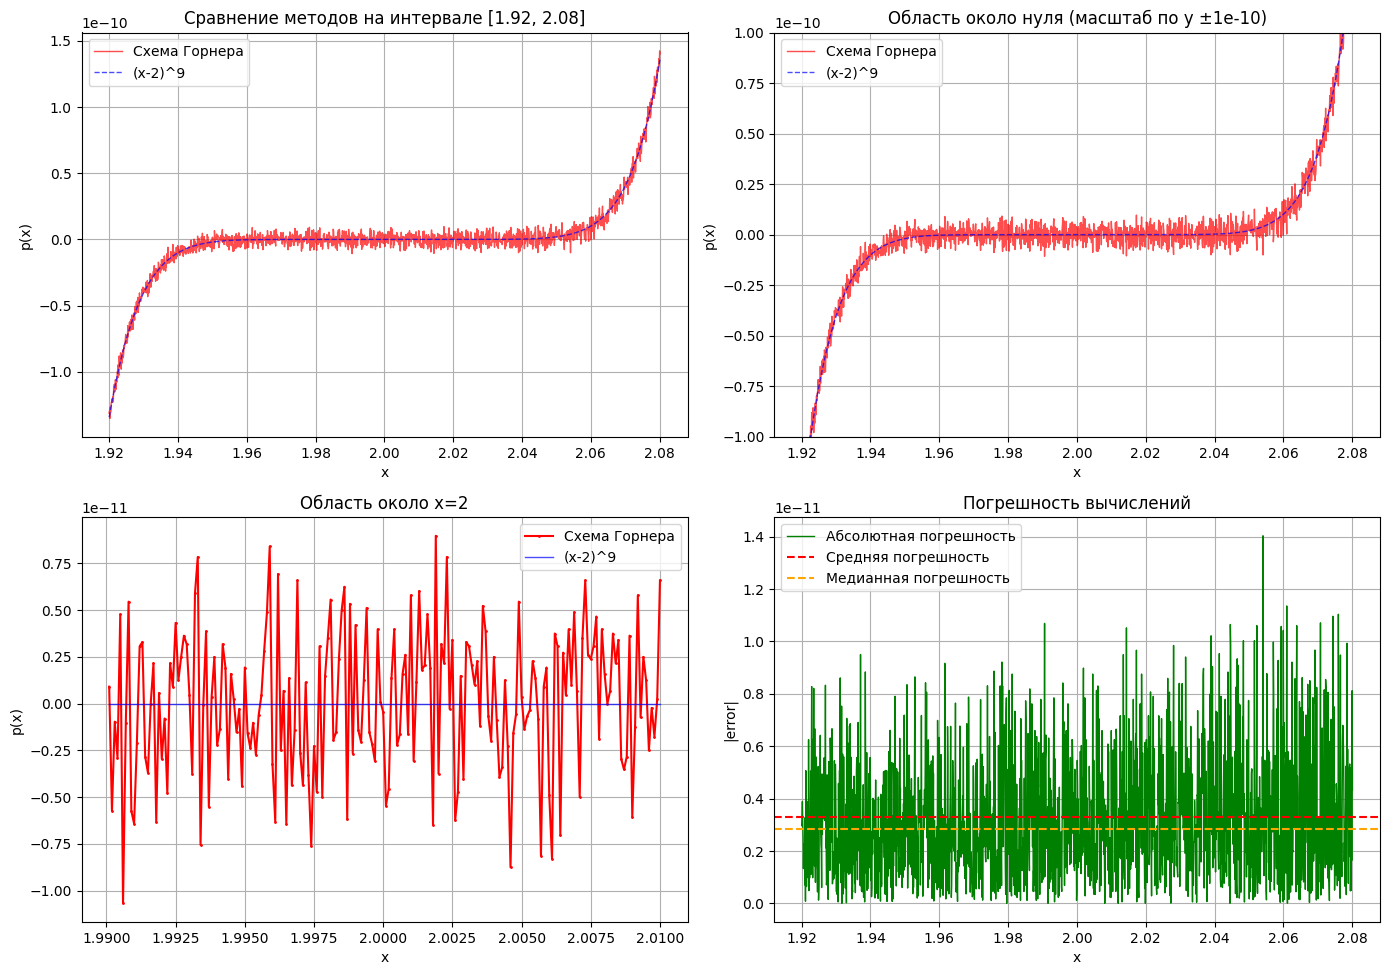


Анализ вблизи корня (|x-2| < 0.01):
Макс. погрешность: 1.07e-11
Средняя погрешность: 3.14e-12


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

def get_coeffs():
    n = 9
    coeffs = []
    for j in range(0, n + 1):
        coeff = math.comb(n, j) * ((-2) ** (n - j))
        coeffs.append(coeff)
    return coeffs

def horner(x, coeffs):
    n = len(coeffs) - 1
    p = coeffs[n]
    for j in range(n - 1, -1, -1):
        p = x * p + coeffs[j]
    return p

def direct_calc(x):
    return (x - 2) ** 9

def main():
    start = 1.92
    end = 2.08
    step = 1e-4

    x_values = np.arange(start, end + step, step)

    coeffs = get_coeffs()
    print("Коэффициенты многочлена (x-2)^9:")
    for i, c in enumerate(coeffs):
        print(f"a_{i} = {c:.0f}")

    horner_values = np.array([horner(x, coeffs) for x in x_values])
    direct_values = direct_calc(x_values)

    error = np.abs(horner_values - direct_values)
    print("\nАнализ погрешности:")
    print(f"Максимальная погрешность: {np.max(error):.2e}")
    print(f"Средняя погрешность: {np.mean(error):.2e}")
    print(f"Медианная погрешность: {np.median(error):.2e}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(x_values, horner_values, 'r-', alpha=0.7, label='Схема Горнера', linewidth=1)
    axes[0, 0].plot(x_values, direct_values, 'b--', alpha=0.7, label='(x-2)^9', linewidth=1)
    axes[0, 0].set_xlabel('x')
    axes[0, 0].set_ylabel('p(x)')
    axes[0, 0].set_title('Сравнение методов на интервале [1.92, 2.08]')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(x_values, horner_values, 'r-', alpha=0.7, label='Схема Горнера', linewidth=1)
    axes[0, 1].plot(x_values, direct_values, 'b--', alpha=0.7, label='(x-2)^9', linewidth=1)
    axes[0, 1].set_xlabel('x')
    axes[0, 1].set_ylabel('p(x)')
    axes[0, 1].set_title('Область около нуля (масштаб по y ±1e-10)')
    axes[0, 1].set_ylim(-1e-10, 1e-10)
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    mask = (x_values >= 1.99) & (x_values <= 2.01)
    axes[1, 0].plot(x_values[mask], horner_values[mask], 'r.-', markersize=2, label='Схема Горнера')
    axes[1, 0].plot(x_values[mask], direct_values[mask], 'b-', alpha=0.7, label='(x-2)^9', linewidth=1)
    axes[1, 0].set_xlabel('x')
    axes[1, 0].set_ylabel('p(x)')
    axes[1, 0].set_title('Область около x=2')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(x_values, error, 'g-', label='Абсолютная погрешность', linewidth=1)
    axes[1, 1].axhline(y=np.mean(error), color='r', linestyle='--', label='Средняя погрешность')
    axes[1, 1].axhline(y=np.median(error), color='orange', linestyle='--', label='Медианная погрешность')
    axes[1, 1].set_xlabel('x')
    axes[1, 1].set_ylabel('|error|')
    axes[1, 1].set_title('Погрешность вычислений')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

    print("\nАнализ вблизи корня (|x-2| < 0.01):")
    near_root = np.abs(x_values - 2) < 0.01
    if np.any(near_root):
        max_err_near = np.max(error[near_root])
        mean_err_near = np.mean(error[near_root])
        print(f"Макс. погрешность: {max_err_near:.2e}")
        print(f"Средняя погрешность: {mean_err_near:.2e}")

if __name__ == "__main__":
    main()

Схема Горнера очень сильно неточна при близости к корню из-за увеличенной роли ошибки округления при действии вычитания с большими числами. При значении многочлена порядка epsilon ошибка округления в коэффициент при степени раз больше, что снижает смысл использования такой схемы вблизи корней.

ДОПОЛЕНЕНИЕ

1. При разложении многочлена $p(x) = (x - 2)^9$ по степеням $x$ получаем:

$$
p(x) = \sum_{j=0}^{9} a_j x^j, \quad a_j = \binom{9}{j} (-2)^{9-j}
$$

Коэффициенты $a_j$ достигают значений порядка $10^3 - 10^4$ (например, $|a_4| \approx 4032$). При $x \approx 2$ каждый член $a_j x^j$ также имеет величину порядка $10^3 - 10^4$, но они суммируются с чередующимися знаками. В результате происходит вычитание близких по величине больших чисел, что приводит к потере точности.

2. Оценка погрешности при вычитании больших чисел

Если два числа $A$ и $B$ вычислены с относительной погрешностью $\varepsilon \approx 10^{-16}$ (машинная точность для float64), то при вычислении их разности:

- Абсолютная погрешность: $\Delta \approx \varepsilon \cdot |A|$
- При $|A| \approx 10^4$ и $|A - B| \approx 10^{-10}$ относительная погрешность результата:

$$
\frac{\Delta}{|A - B|} \approx \frac{10^{-16} \cdot 10^4}{10^{-10}} \approx 10^{-2}
$$

Таким образом, мы теряем около двух значащих цифр, что объясняет наблюдаемую погрешность порядка $10^{-11}$.

3. Схема Горнера минимизирует количество арифметических операций и обычно дает меньшую погрешность по сравнению с прямым суммированием $\sum a_j x^j$.

Основная проблема заключается в форме представления многочлена. Использование разложения по степеням $x$ при $x \approx 2$ приводит к операциям вычитания больших чисел.

4. Прямое вычисление $\sum_{j=0}^9 a_j x^j$ (без использования схемы Горнера) было бы даже хуже, поскольку требует больше арифметических операций, приводит к большему числу промежуточных округлений.

5. Если из-за вычислительной погрешности значение функции колеблется в пределах $\pm 10^{-11}$, становится невозможным отличить истинный ноль функции от вычислительного шума.


6. Итог
Схема Горнера непригодна для численного определения нуля функции в данном случае из-за потери точности при вычитании больших чисел. Эта проблема является следствием неудачного представления многочлена (разложение по степеням $x$), а не недостатком самого алгоритма Горнера. Для надежного определения корней следует использовать представление функции, минимизирующее операции вычитания близких больших чисел.